Reducing dimensions of the distance matrix with PCA to prepare for clustering.

In [ ]:
!pip install scikit-learn #Installing sklearn
!pip install matplotlib #Installing matplotlib


from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [ ]:
df_distance_matrix = pd.read_csv('../blasting/distance_matrix.csv', index_col=0) #Reading the distance matrix into a Dataframe

pca = PCA(n_components=3) #Saves amount of components to variable "pca"
principal_components_MSA = pca.fit_transform(df_distance_matrix)  #Saves matrix transformed through PCA 

print(pca.explained_variance_ratio_) #Prints the explained variance of each Principal Component

pd.DataFrame(principal_components_MSA, index=df_distance_matrix.index, columns=['PC1', 'PC2', 'PC3']).to_csv('../blasting/principal_components.csv')



[0.61343965 0.27686388 0.07078182]


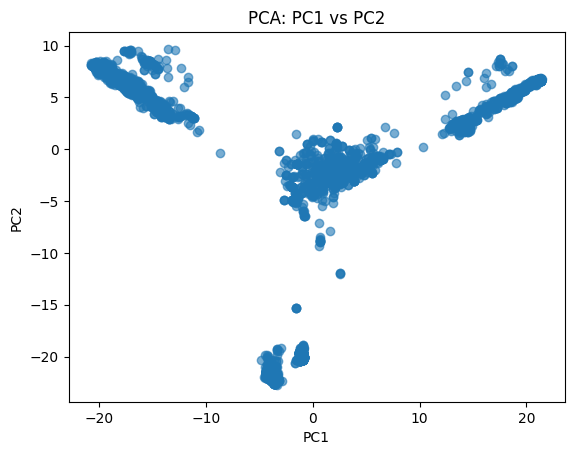

In [ ]:
plt.scatter(principal_components_MSA[:, 0], principal_components_MSA[:, 1], alpha=0.6) #Generating Graphical Representation of PCA 1 and 2
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2')
plt.show()


Now after completing the PCA we will use the reduced Data to identify clusters using k-means clustering.

In [8]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sequence_ids = df_distance_matrix.index.tolist()

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(principal_components_MSA)
labels = kmeans.labels_

# Now create the DataFrame after labels are ready
df_clusters = pd.DataFrame(principal_components_MSA, columns=['PC1', 'PC2', 'PC3'], index=sequence_ids)
df_clusters['Cluster'] = labels

print(df_clusters.head())

df_clusters.to_csv('pca_clusters.csv')



                       PC1       PC2       PC3  Cluster
7ZOZ_1|A|Homo     1.166747 -1.673868  9.451882        0
7ZOZ_2|H|Homo   -17.642245  6.522956 -0.793466        2
7ZOZ_3|L|Homo    19.177278  5.641768 -2.818275        1
6PE8_1|A,H|Homo -20.307069  8.373705 -2.723105        2
6PE8_2|B,L|Homo  19.915672  5.947782 -3.378541        1


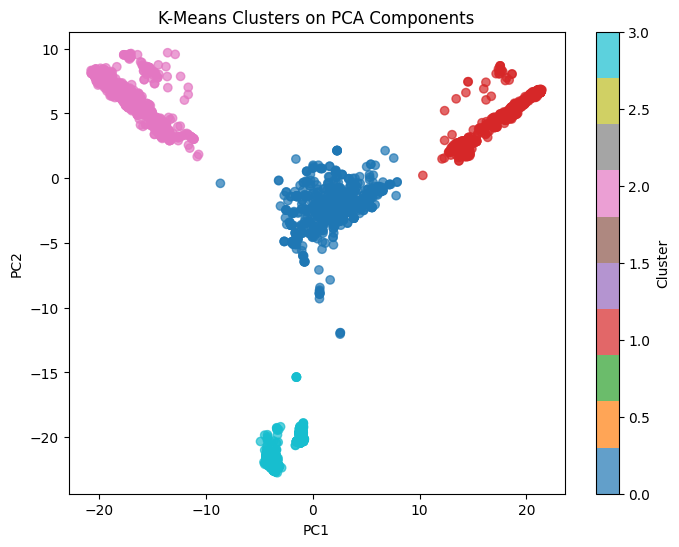

In [ ]:
import matplotlib.pyplot as plt #Visualizing the Clusters

plt.figure(figsize=(8,6))
scatter = plt.scatter(df_clusters['PC1'], df_clusters['PC2'], c=df_clusters['Cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters on PCA Components')
plt.colorbar(scatter, label='Cluster')
plt.show()
